Importation

In [14]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Charger le dataset

In [15]:
transform=transforms.ToTensor()
train_data= datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

Afficher une image MNIST

Label: 5


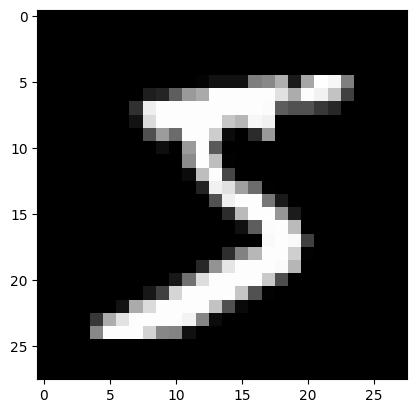

In [16]:
image, label = train_data[0]

print("Label:", label)
plot.imshow(image.squeeze(), cmap="gray")
plot.show()

**DataLoader**
c'est un outil qui prend le dataset et le decoupe en petits groupes (batch)

In [19]:
from torch.utils.data import DataLoader
train_loader=DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

**Tester**

In [20]:
images,labels=next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


**Construire le modéle MNIST**

In [22]:
import torch.nn as nn
model= nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28,128),
    nn.ReLU(),
    nn.Linear(128,10)
)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


**définir loss + optimizer**

In [23]:
from torch.optim import optimizer
import torch.optim as optim
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


**Entrainement**

In [26]:
for epoch in range(10):
  for images, labels in train_loader:
    outputs=model(images)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 1, Loss = 0.6479
Epoch 2, Loss = 0.2712
Epoch 3, Loss = 0.2836
Epoch 4, Loss = 0.0493
Epoch 5, Loss = 0.0033
Epoch 6, Loss = 0.0027
Epoch 7, Loss = 0.0674
Epoch 8, Loss = 0.0384
Epoch 9, Loss = 0.0063
Epoch 10, Loss = 0.0044


Epoch 10, Loss = 0.0044


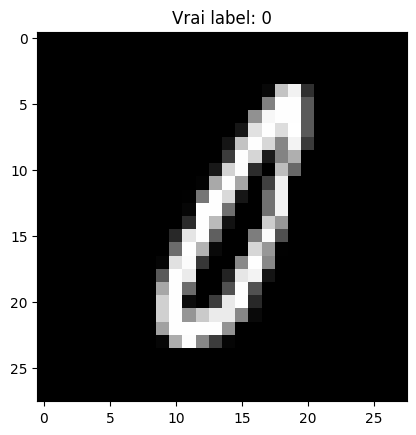

Prédiction du modèle : 0


In [31]:
  print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")
  # prendre une image
image = images[3]
label = labels[3]

# afficher
import matplotlib.pyplot as plt
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Vrai label: {label}")
plt.show()

# prédiction
with torch.no_grad():
    output = model(image.unsqueeze(0))
    predicted = torch.argmax(output)

print("Prédiction du modèle :", predicted.item())

